# Importing all required libraries and functions

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

### Loading the dataset downloaded from the UC Irvine Machine Learning Repository: "Bank Marketing"

In [2]:
data = pd.read_csv("bank-additional-full.csv",sep=";")

In [3]:
data.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Variable descriptions:

- age – client's age
- job – type of employment
- marital – marital status
- education – level of education
- default – whether the client has credit in default
- housing – whether the client has a housing loan
- loan – whether the client has a personal loan
- contact – type of communication (cellular/telephone)
- month – month of the last contact
- day_of_week – day of the week of the last contact
- duration – duration of the last call in seconds (removed)
- campaign – number of contacts made during this campaign
- pdays – number of days since the client was last contacted in a previous campaign (999 = no previous contact)
- previous – number of contacts made before this campaign
- poutcome – outcome of the previous marketing campaign
- emp.var.rate – employment variation rate (quarterly)
- cons.price.idx – consumer price index (monthly)
- cons.conf.idx – consumer confidence index (monthly)
- euribor3m – Euribor 3-month rate (daily)
- nr.employed – number of employees in the economy (quarterly, unofficial description)
- y – whether the client subscribed to a term deposit (target variable)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
data = data.replace('unknown', np.nan)

nan_counts = data.isna().sum()
nan_counts = nan_counts[nan_counts > 0]

print("Missing values per column:")
for col, n in nan_counts.items():
    print(f"{col}: {n} ({n/len(data)*100:.1f}%)")

Missing values per column:
job: 330 (0.8%)
marital: 80 (0.2%)
education: 1731 (4.2%)
default: 8597 (20.9%)
housing: 990 (2.4%)
loan: 990 (2.4%)


The structural analysis of the dataset (`data.info()`)  shows no formal missing values (NaN). However, in this dataset missing data in the categorical columns is encoded as the string "unknown", which pandas treats as a regular value. After replacing "unknown" with NaN, the actual scale of missing data becomes visible: it affects six categorical columns, most notably default (20.9%), while the remaining columns range from 0.2% to 4.2%. These missing values will be handled within the preprocessing pipeline using SimpleImputer with the most_frequent strategy, ensuring that the imputation is fitted only on the training folds during cross-validation and does not leak information from the test set. The target variable is already encoded as column 'y'. In the next step, we will divide the features into numerical and categorical variables.

In [6]:
num_features = data.select_dtypes(include=np.number).columns
cat_features = data.select_dtypes(exclude=np.number).columns
print(f"Categorical variables: {', '.join(cat_features)}")
print(f"Numerical variables: {', '.join(num_features)}")

Categorical variables: job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome, y
Numerical variables: age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed


We will now verify whether the dataset suffers from a class imbalance problem.

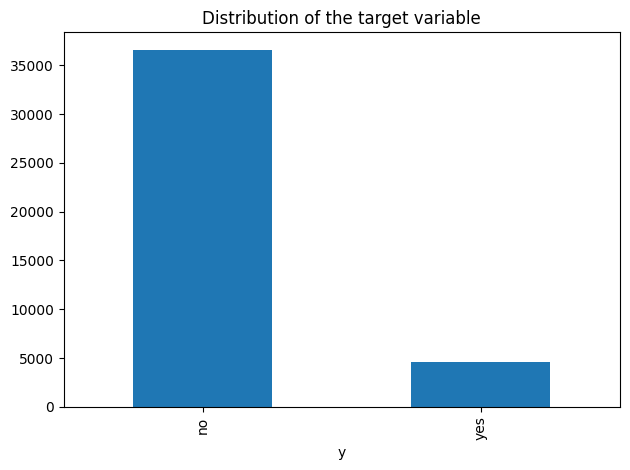

Data distribution in %:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [7]:
data['y'].value_counts().plot(kind='bar')
plt.title('Distribution of the target variable')
plt.tight_layout()
plt.show()
print(f"Data distribution in %:\n{data['y'].value_counts(normalize=True) * 100}")

The chart and percentage distribution confirm a clear class imbalance problem. In the following steps, we will select an appropriate method to address this issue.

We proceed to split the data into training and test sets.

In [8]:
X = data.drop(columns=['y', 'duration'])
Y = data['y']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42)

In [9]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(32950, 19)
(32950,)
(8238, 19)
(8238,)


In [10]:
num_train = X_train.select_dtypes(include='number').columns.tolist()
cat_train = X_train.select_dtypes(include='object').columns.tolist()
X_train[num_train].describe()
X_train[cat_train]

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
12556,blue-collar,married,basic.9y,NaN,yes,no,telephone,jul,mon,nonexistent
35451,admin.,married,university.degree,no,no,no,cellular,may,mon,nonexistent
30592,retired,married,basic.4y,no,no,no,cellular,may,mon,failure
17914,housemaid,divorced,basic.9y,no,yes,no,cellular,jul,tue,nonexistent
3315,admin.,single,high.school,NaN,no,no,telephone,may,thu,nonexistent
...,...,...,...,...,...,...,...,...,...,...
6265,retired,married,professional.course,NaN,no,no,telephone,may,tue,nonexistent
11284,management,married,university.degree,no,no,no,telephone,jun,thu,nonexistent
38158,admin.,married,high.school,no,yes,no,cellular,oct,thu,success
860,management,married,university.degree,no,yes,no,telephone,may,wed,nonexistent


In [11]:
print(num_train)

['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [12]:
X_train[num_train].corr().style.background_gradient(cmap='coolwarm')

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,0.008029,-0.037208,0.024633,0.000654,0.005697,0.127198,0.011134,-0.018225
campaign,0.008029,1.000000,0.052099,-0.078620,0.151636,0.128344,-0.012813,0.135814,0.144444
pdays,-0.037208,0.052099,1.000000,-0.582945,0.270013,0.075696,-0.089145,0.296115,0.372276
previous,0.024633,-0.078620,-0.582945,1.000000,-0.421517,-0.204443,-0.052983,-0.454779,-0.500476
emp.var.rate,0.000654,0.151636,0.270013,-0.421517,1.000000,0.773785,0.194588,0.972084,0.906548
cons.price.idx,0.005697,0.128344,0.075696,-0.204443,0.773785,1.000000,0.057473,0.685909,0.519113
cons.conf.idx,0.127198,-0.012813,-0.089145,-0.052983,0.194588,0.057473,1.000000,0.276002,0.099097
euribor3m,0.011134,0.135814,0.296115,-0.454779,0.972084,0.685909,0.276002,1.000000,0.945144
nr.employed,-0.018225,0.144444,0.372276,-0.500476,0.906548,0.519113,0.099097,0.945144,1.000000


Conclusions:

The correlation matrix analysis reveals very strong multicollinearity among the macroeconomic variables, suggesting they largely represent the same information about the state of the economy:

- emp.var.rate – euribor3m: 0.97
- emp.var.rate – nr.employed: 0.91
- euribor3m – nr.employed: 0.95

Due to this high level of correlation, we will decide to reduce the number of these variables in the subsequent steps in order to mitigate the multicollinearity problem (particularly relevant for linear models such as logistic regression).


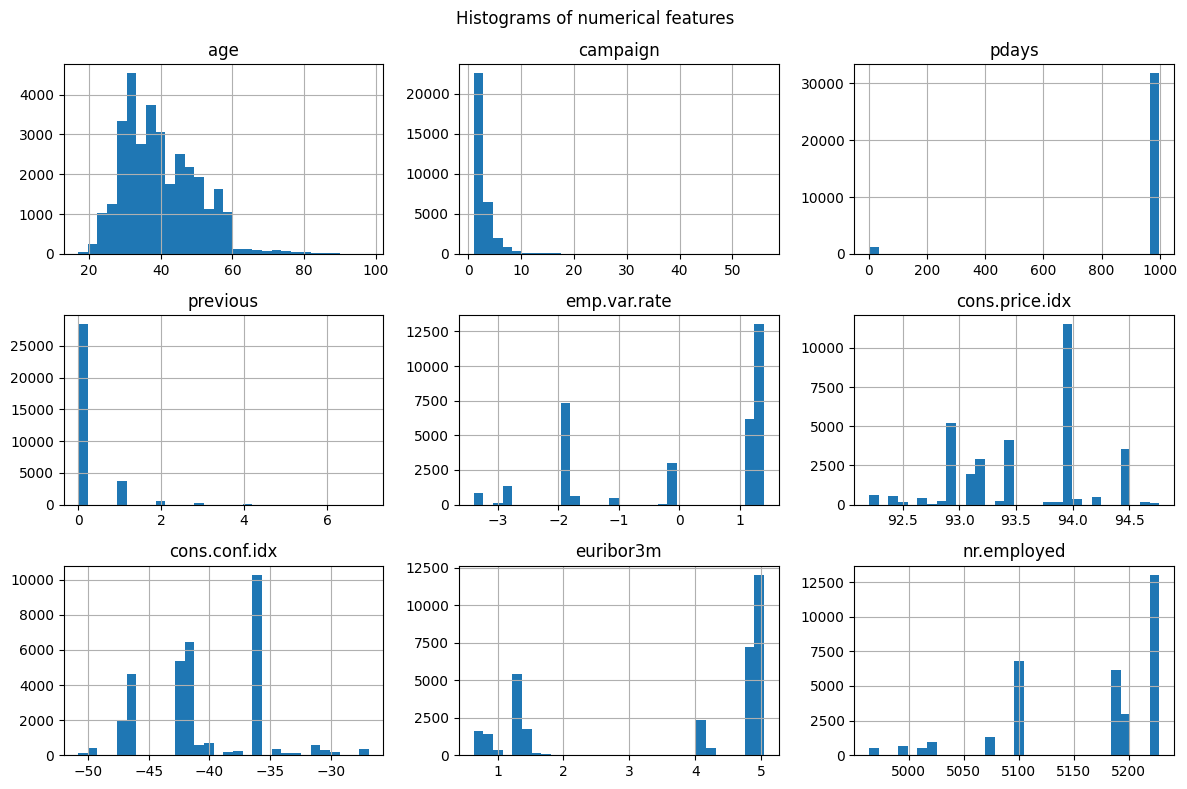

In [13]:
X_train[num_train].hist(bins=30,figsize=(12,8))
plt.suptitle("Histograms of numerical features")
plt.tight_layout()
plt.show()

Conclusions:

- age – distribution closest to normal
- campaign – the vast majority of clients were contacted 1–2 times
- pdays – dominant value of 999, indicating no previous contact with the client
- previous – in the vast majority of cases the client had no prior contacts (value 0)
- emp.var.rate, euribor3m, nr.employed, cons.price.idx – clear bimodal distributions, reflecting two distinct economic periods present in the data

### Outlier Analysis

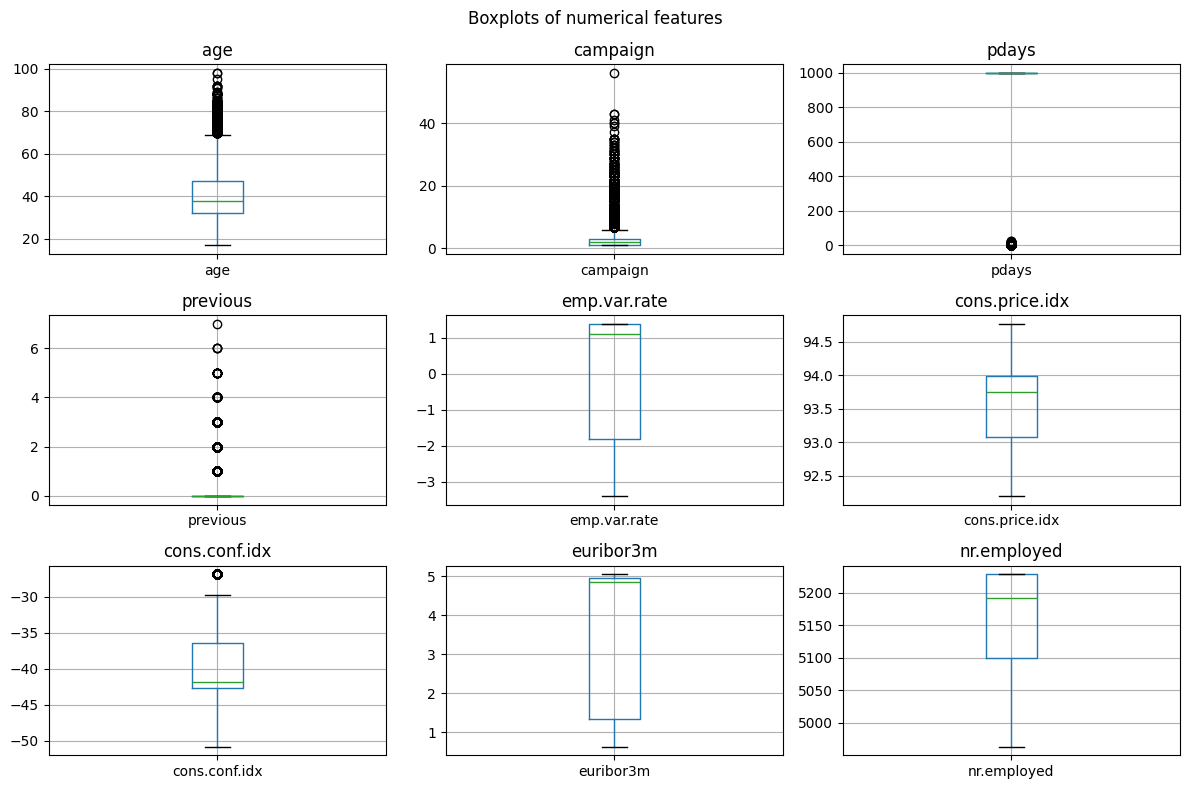

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_train):
    X_train.boxplot(column=[col], ax=axes[i])
    axes[i].set_title(col)

plt.suptitle("Boxplots of numerical features")
plt.tight_layout()
plt.show()

Conclusions:

- age – a few observations above 80–90 years, but the overall distribution remains reasonably symmetric
- campaign – median around 2, with a substantial number of outliers reaching 40 and above, confirming the strong right skew
- previous – median equal to 0, outliers reach a maximum of 7
- pdays – due to the specific encoding of this variable (dominant value of 999), the boxplot carries virtually no interpretable information
- cons.conf.idx – a single outlier around -29
- emp.var.rate, cons.price.idx, euribor3m, nr.employed – no significant outliers

In [15]:
z_scores = np.abs(stats.zscore(X_train[num_train]))
outliers_z = (z_scores > 3).any(axis=1)

print(f"Number of outliers by Z-score: {outliers_z.sum()}")
print(f"Percent: {outliers_z.mean()*100:.1f}%")

Number of outliers by Z-score: 2461
Percent: 7.5%


Conclusions:

The Z-score method identified 2,461 observations (~7.5%) that deviate by more than 3 standard deviations from the mean in at least one feature. This is a relatively high proportion, confirming the strong skewness of certain variable distributions. The primary source of this phenomenon is likely the "campaign" and "previous" variables, as confirmed by the box plots analysed earlier.

In [16]:
Q1 = X_train[num_train].quantile(0.25)
Q3 = X_train[num_train].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((X_train[num_train] < Q1 - 1.5 * IQR) | (X_train[num_train] > Q3 + 1.5 * IQR)).any(axis=1)

print(f"Number of outliers by IQR: {outliers_iqr.sum()}")
print(f"Percent: {outliers_iqr.mean()*100:.1f}%")

Number of outliers by IQR: 6767
Percent: 20.5%


Conclusions:

Due to the heavily skewed distributions of features such as "campaign" and "previous", the IQR method detected as many as 20.5% of observations as outliers. Removing such a large number of records would result in a significant loss of information. Therefore, we decided to apply outlier capping rather than removal.

Summary:

The exploratory data analysis suggests the following steps for further processing:

1. "pdays" variable – we will create an additional binary variable contacted_before (value 1 if pdays differs from 999, otherwise 0).
2. We will apply outlier capping to limit the influence of extreme values.
3. All numerical features will be standardised using StandardScaler.
4. Categorical variables (of type object) will be encoded using One-Hot Encoding.
5. We will address the class imbalance problem of the target variable.
6. We will reduce the strong multicollinearity among the macroeconomic variables.
7. Missing values (encoded as 'unknown') will be imputed within the pipeline


In [17]:
X_train['contacted_before'] = (X_train['pdays'] != 999).astype(int)
X_test['contacted_before'] = (X_test['pdays'] != 999).astype(int)

X_train = X_train.drop(columns=['pdays'])
X_test = X_test.drop(columns=['pdays'])

# Due to strong correlation
X_train = X_train.drop(columns=['emp.var.rate', 'nr.employed'])
X_test = X_test.drop(columns=['emp.var.rate', 'nr.employed'])

num_train = X_train.select_dtypes(include='number').columns.tolist()
cat_train = X_train.select_dtypes(include='object').columns.tolist()

## Baseline – Reference Model (Dummy Classifier)

Before comparing the trained models, we establish a reference point in the form of the simplest possible classifier that does not exploit any real patterns in the data. The DummyClassifier with the "most_frequent" strategy always predicts the dominant class (in our case "no"), regardless of feature values.

Comparing the results of the proper models against this baseline allows us to assess whether they actually learn meaningful patterns from the data, or merely reflect the imbalanced class distribution. This is particularly important in the context of the Accuracy metric, which for the baseline can take a high value (close to the proportion of the majority class) despite being completely ineffective at detecting the "yes" class.

In [18]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
Y_pred_dummy = cross_val_predict(dummy, X_train, Y_train, cv=5)

acc_dummy = accuracy_score(Y_train, Y_pred_dummy)
prec_dummy = precision_score(Y_train, Y_pred_dummy, pos_label='yes', zero_division=0)
rec_dummy = recall_score(Y_train, Y_pred_dummy, pos_label='yes', zero_division=0)
f1_dummy = f1_score(Y_train, Y_pred_dummy, pos_label='yes', zero_division=0)

Y_pred_dummy_proba = cross_val_predict(dummy, X_train, Y_train, cv=5, method='predict_proba')[:,1]
auc_dummy = roc_auc_score(Y_train, Y_pred_dummy_proba)

We build the data preprocessing pipelines and define the classification models to be evaluated. We prepare two separate processing branches: one for numerical variables (outlier capping, median imputation, standardisation) and one for categorical variables (mode imputation, One-Hot Encoding), which are then combined using ColumnTransformer.

Three classification algorithms were selected for comparison, each representing a different learning approach:

1. Logistic Regression – a single, simple linear model serving as an interpretable baseline for more complex methods.
2. Random Forest – an ensemble model based on parallel learning (bagging), in which multiple decision trees are trained independently and the final prediction is obtained by aggregating their outputs.
3. Gradient Boosting (HistGradientBoostingClassifier) – an ensemble model based on sequential learning (boosting), in which successive trees are built iteratively, correcting the errors made by the previous ones.

All models use the `class_weight='balanced'` parameter to partially address the class imbalance problem.

In [19]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, mnoznik=1.5):
        self.mnoznik = mnoznik

    def fit(self, X, y=None):
        q1 = np.percentile(X, 25, axis=0)
        q3 = np.percentile(X, 75, axis=0)
        iqr = q3 - q1
        self.dolna_granica_ = q1 - self.mnoznik * iqr
        self.gorna_granica_ = q3 + self.mnoznik * iqr
        return self

    def transform(self, X, y=None):
        return np.clip(X, self.dolna_granica_, self.gorna_granica_)

In [20]:
num_pipeline = Pipeline(steps=[
    ("capper", OutlierCapper()),
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

In [21]:
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown = 'ignore'))
])


In [22]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_train),
    ('cat', cat_pipeline, cat_train)
])

In [23]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000,random_state=42, class_weight='balanced'))
])

In [24]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

In [25]:
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42, class_weight='balanced'))
])

We apply 5-fold cross-validation to obtain a reliable estimate of each model's performance, independent of any particular random split of the training data.

In [26]:
# Logistic Regression
Y_pred_lr = cross_val_predict(pipeline_lr, X_train, Y_train, cv =5)

In [27]:
# Random forest
Y_pred_rf = cross_val_predict(pipeline_rf, X_train, Y_train, cv = 5)

In [28]:
# Gradient boosting
Y_pred_gb = cross_val_predict(pipeline_gb, X_train, Y_train, cv = 5)

We now evaluate the quality of each model based on the predictions obtained through cross-validation. For each algorithm, we compute four core classification metrics:

- Accuracy – the overall proportion of correct predictions; however, due to class imbalance, this metric has limited interpretive value.
- Precision – what proportion of clients predicted as "yes" by the model actually responded positively.
- Recall – what proportion of all actual "yes" responses the model correctly identified.
- F1 Score – the harmonic mean of precision and recall, used as the primary comparison metric given the class imbalance.

Additionally, for each model we will compute:

- Confusion Matrix – providing a detailed breakdown of correct and incorrect classifications by class.
- ROC Curve and AUC – illustrating the model's ability to distinguish between classes independently of the chosen decision threshold.

The numerical results for individual models will be discussed together in the summary comparison table.

### Logistic Regression Evaluation

In [29]:
acc_lr = accuracy_score(Y_train,Y_pred_lr)
prec_lr = precision_score(Y_train,Y_pred_lr,pos_label='yes')
rec_lr = recall_score(Y_train,Y_pred_lr,pos_label='yes')
f1_lr = f1_score(Y_train,Y_pred_lr,pos_label='yes')

print(f"Accuracy: {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall: {rec_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}")

Accuracy: 0.8222
Precision: 0.3429
Recall: 0.6345
F1 Score: 0.4452


### Random Forest Evaluation

In [30]:
acc_rf = accuracy_score(Y_train,Y_pred_rf)
prec_rf = precision_score(Y_train,Y_pred_rf,pos_label='yes')
rec_rf = recall_score(Y_train,Y_pred_rf,pos_label='yes')
f1_rf = f1_score(Y_train,Y_pred_rf,pos_label='yes')

print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

Accuracy: 0.8925
Precision: 0.5426
Recall: 0.2821
F1 Score: 0.3712


### Gradient Boosting Evaluation

In [31]:
acc_gb = accuracy_score(Y_train,Y_pred_gb)
prec_gb = precision_score(Y_train,Y_pred_gb,pos_label='yes')
rec_gb = recall_score(Y_train,Y_pred_gb,pos_label='yes')
f1_gb = f1_score(Y_train,Y_pred_gb,pos_label='yes')

print(f"Accuracy: {acc_gb:.4f}")
print(f"Precision: {prec_gb:.4f}")
print(f"Recall: {rec_gb:.4f}")
print(f"F1 Score: {f1_gb:.4f}")

Accuracy: 0.8452
Precision: 0.3858
Recall: 0.6359
F1 Score: 0.4802


### Confusion Matrices

[[24739  4506]
 [ 1354  2351]]


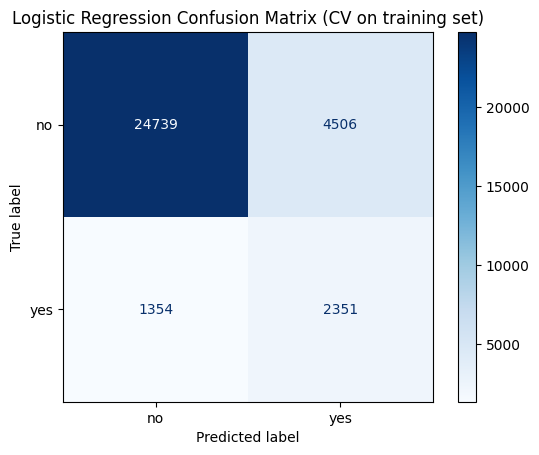

In [32]:
cm = confusion_matrix(Y_train,Y_pred_lr)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['no','yes'])
disp.plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix (CV on training set)")
plt.show()

[[28364   881]
 [ 2660  1045]]


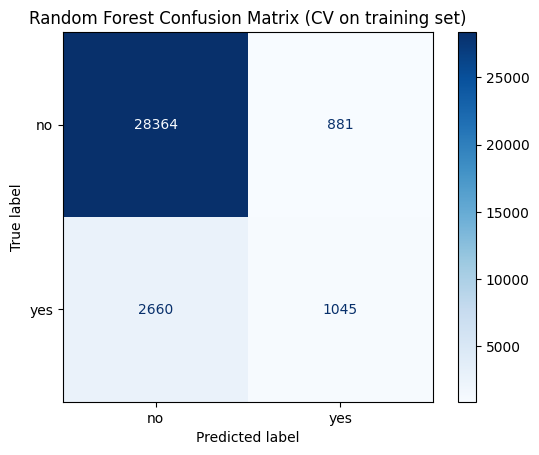

In [33]:
cm = confusion_matrix(Y_train,Y_pred_rf)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['no','yes'])
disp.plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix (CV on training set)")
plt.show()

[[25494  3751]
 [ 1349  2356]]


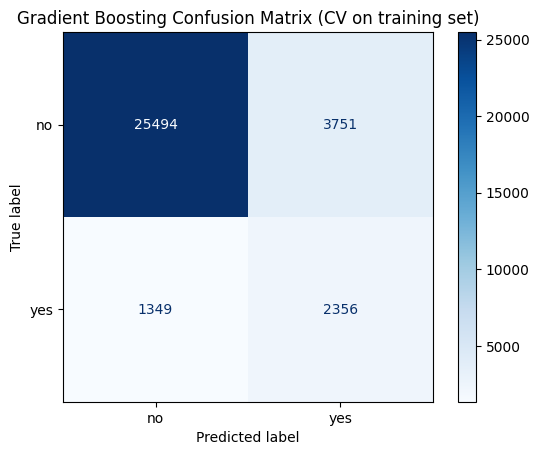

In [34]:
cm = confusion_matrix(Y_train,Y_pred_gb)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['no','yes'])
disp.plot(cmap='Blues')
plt.title("Gradient Boosting Confusion Matrix (CV on training set)")
plt.show()

### ROC Curve and AUC

In [35]:
Y_pred_lr_proba = cross_val_predict(pipeline_lr, X_train, Y_train, cv=5, method='predict_proba')[:,1]
Y_pred_rf_proba = cross_val_predict(pipeline_rf, X_train, Y_train, cv=5, method='predict_proba')[:,1]
Y_pred_gb_proba = cross_val_predict(pipeline_gb, X_train, Y_train, cv=5, method='predict_proba')[:,1]

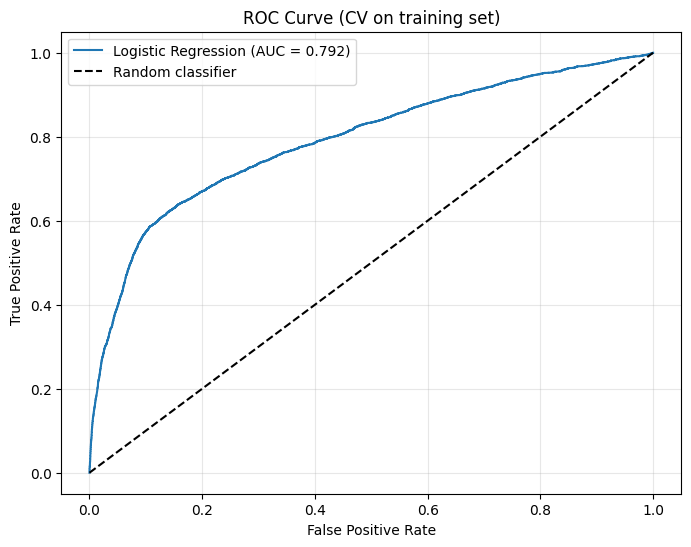

In [36]:
fpr_lr, tpr_lr, thresholds_lr = roc_curve(Y_train,Y_pred_lr_proba,pos_label='yes')
auc_score_lr = roc_auc_score(Y_train,Y_pred_lr_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_score_lr:.3f})")
plt.plot([0,1],[0,1],'k--', label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CV on training set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

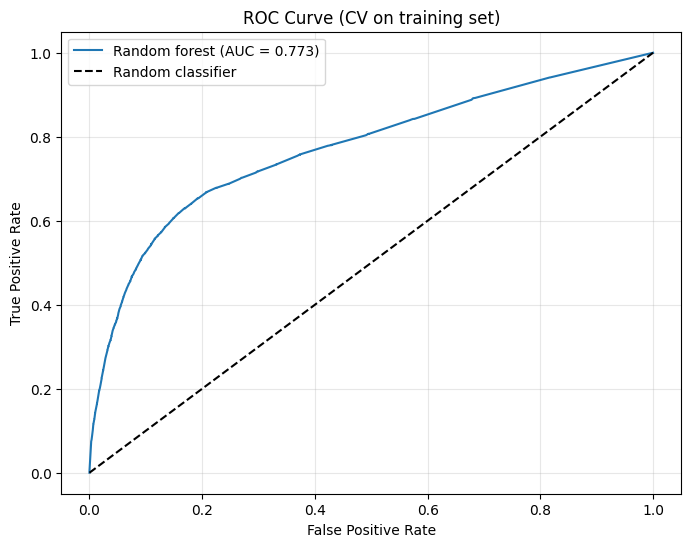

In [37]:
fpr_rf, tpr_rf, thresholds_lr = roc_curve(Y_train,Y_pred_rf_proba,pos_label='yes')
auc_score_rf = roc_auc_score(Y_train,Y_pred_rf_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random forest (AUC = {auc_score_rf:.3f})")
plt.plot([0,1],[0,1],'k--', label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CV on training set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

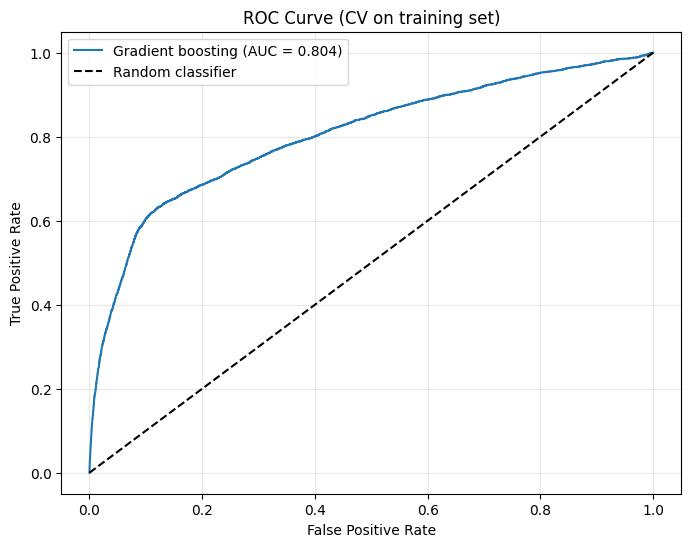

In [38]:
fpr_gb, tpr_gb, thresholds_gb = roc_curve(Y_train,Y_pred_gb_proba,pos_label='yes')
auc_score_gb = roc_auc_score(Y_train,Y_pred_gb_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_gb, tpr_gb, label=f"Gradient boosting (AUC = {auc_score_gb:.3f})")
plt.plot([0,1],[0,1],'k--', label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CV on training set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
wyniki = pd.DataFrame({
    'Model': ['Dummy Classifier', 'Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [acc_dummy,
                 acc_lr,
                 acc_rf,
                 acc_gb],
    'Precision': [prec_dummy,
                  prec_lr,
                  prec_rf,
                  prec_gb],
    'Recall': [rec_dummy,
               rec_lr,
               rec_rf,
               rec_gb],
    'F1': [f1_dummy,
           f1_lr,
           f1_rf,
           f1_gb],
    'AUC': [auc_dummy,
            auc_score_lr,
            auc_score_rf,
            auc_score_gb]
})

wyniki.set_index('Model').round(4)

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Dummy Classifier,0.8876,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.8222,0.3429,0.6345,0.4452,0.7918
Random Forest,0.8925,0.5426,0.2821,0.3712,0.7731
Gradient Boosting,0.8452,0.3858,0.6359,0.4802,0.8042


Conclusions:
Comparison with the baseline (Dummy Classifier) clearly confirms that the trained models learn meaningful patterns from the data. While the DummyClassifier ("most_frequent" strategy) achieves F1=0 and AUC=0.5 (the level of random guessing), all three proper models obtain F1 scores in the range 0.37–0.48 and AUC above 0.77, representing a clear and substantial improvement over the simplest possible reference point.

The results also reveal notable differences between the models themselves, particularly evident when accounting for the class imbalance. Although Random Forest achieved the highest Accuracy (0.8925), this metric is misleading in this context, the model has the lowest Recall (0.2821), meaning it detects only approximately 28% of clients genuinely interested in the offer. This is likely attributable to the fact that the bagging mechanism, despite the use of class_weight='balanced', is less effective at handling the dominance of the majority class than the sequential boosting approach.

Gradient Boosting achieved the best results in terms of F1 (0.4802) and AUC (0.8042), narrowly outperforming Logistic Regression (F1=0.4452, AUC=0.7918). The high Recall (0.6359) combined with moderate Precision (0.3858) indicates that the model effectively identifies the majority of clients interested in the offer, at the cost of some false positive predictions — a trade-off that is generally acceptable in a marketing campaign context (it is preferable to contact more potential clients than to miss those who are genuinely interested).

Due to the best balance between F1 and AUC, Gradient Boosting was selected for further hyperparameter tuning.

## Hyperparameter Tuning

To improve the performance of the selected model (Gradient Boosting), we perform hyperparameter tuning using GridSearchCV, optimising the following parameters:

1. max_iter – number of boosting iterations, corresponding to the number of trees built in the model.
2. learning_rate – learning rate, determining how strongly each successive tree corrects the errors made by the previous one.
3. max_depth – maximum depth of each individual tree.

In [40]:
param_grid = {
    'classifier__max_iter': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5]
}

In [41]:
scorer = make_scorer(f1_score, pos_label='yes')

grid_search = GridSearchCV(
    pipeline_gb,
    param_grid,
    cv=5,
    scoring=scorer,
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1: {grid_search.best_score_:.4f}")

Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__max_iter': 100}
Best F1: 0.4749


Having identified the optimal hyperparameters (learning_rate=0.1, max_depth=5, max_iter=100) using GridSearchCV, we create the final model with the best found configuration and evaluate its actual performance on the test set — data the model has never seen during training or tuning.

In [42]:
best_model = grid_search.best_estimator_
Y_pred_test = best_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(Y_test, Y_pred_test):.4f}")
print(f"Precision: {precision_score(Y_test, Y_pred_test, pos_label='yes'):.4f}")
print(f"Recall:    {recall_score(Y_test, Y_pred_test, pos_label='yes'):.4f}")
print(f"F1:        {f1_score(Y_test, Y_pred_test, pos_label='yes'):.4f}")

Accuracy:  0.8305
Precision: 0.3588
Recall:    0.6267
F1:        0.4564


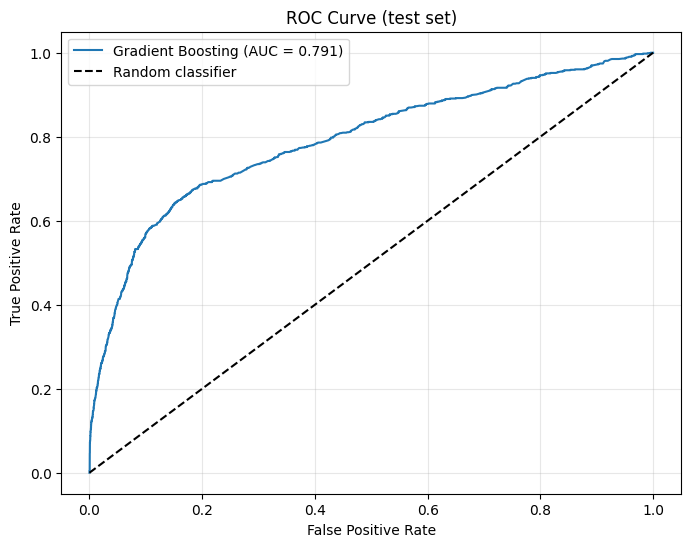

In [43]:
Y_pred_test_proba = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(Y_test, Y_pred_test_proba, pos_label='yes')
auc_score = roc_auc_score(Y_test, Y_pred_test_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {auc_score:.3f})")
plt.plot([0,1],[0,1],'k--', label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (test set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Decision Threshold Optimisation

By default, the `.predict()` method classifies an observation as "yes" if the predicted probability exceeds 0.5. However, this threshold is purely arbitrary and does not account for the specific characteristics of our problem. In a marketing campaign context, the cost of an unnecessary contact with a disinterested client (false positive) is typically lower than the cost of missing a client who would genuinely subscribe (false negative).

In [44]:
proba_train_cv = cross_val_predict(best_model, X_train, Y_train, cv=5, method='predict_proba')[:, 1]

progi = np.arange(0.1, 0.9, 0.01)
f1_dla_progow = [f1_score(Y_train, np.where(proba_train_cv >= p, 'yes', 'no'), pos_label='yes')
                 for p in progi]
najlepszy_prog = progi[np.argmax(f1_dla_progow)]
print(f"Best threshold (selected on training CV): {najlepszy_prog:.2f}, F1 (train CV): {max(f1_dla_progow):.4f}")

Best threshold (selected on training CV): 0.64, F1 (train CV): 0.5100


In [45]:
Y_pred_test_optymalny = np.where(Y_pred_test_proba >= najlepszy_prog, 'yes', 'no')

print(f"Precision: {precision_score(Y_test, Y_pred_test_optymalny, pos_label='yes'):.4f}")
print(f"Recall:    {recall_score(Y_test, Y_pred_test_optymalny, pos_label='yes'):.4f}")
print(f"F1:        {f1_score(Y_test, Y_pred_test_optymalny, pos_label='yes'):.4f}")

Precision: 0.4410
Recall:    0.5401
F1:        0.4856


Conclusions:
Optimising the decision threshold (as opposed to the default value of 0.5) improved F1 from 0.4564 to 0.4856 at a threshold of 0.64. This improvement is driven primarily by a gain in precision (0.3588 -> 0.4410) at the cost of a moderate drop in recall (0.6267 -> 0.5401).

From a business perspective, the choice of threshold should depend on the actual cost of contacting a client relative to the cost of missing a potential subscriber. If the priority is to maximise the number of detected interested clients (high recall), a lower threshold may be more appropriate despite a lower F1. If the goal is to reduce unnecessary contacts while maintaining reasonable effectiveness, a threshold of 0.64 represents a better trade-off.

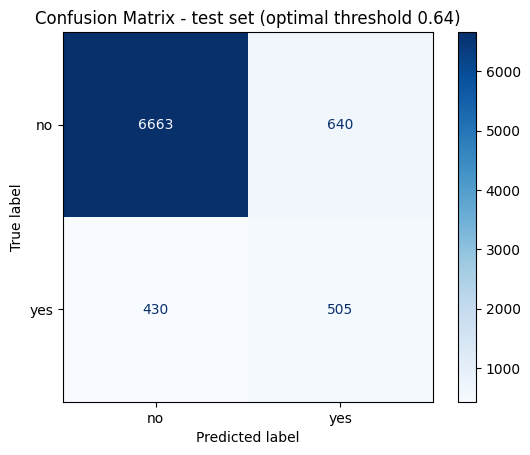

In [46]:
cm = confusion_matrix(Y_test, Y_pred_test_optymalny)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - test set (optimal threshold 0.64)")
plt.show()

In [47]:
wyniki_gb = pd.DataFrame({
    'Model': ['Gradient Boosting'],
    'Accuracy': [accuracy_score(Y_test, Y_pred_test_optymalny)],
    'Precision': [precision_score(Y_test, Y_pred_test_optymalny, pos_label='yes')],
    'Recall': [recall_score(Y_test, Y_pred_test_optymalny, pos_label='yes')],
    'F1': [f1_score(Y_test, Y_pred_test_optymalny, pos_label='yes')],
    'AUC': [auc_score]
})

wyniki_gb.set_index('Model').round(4)

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Gradient Boosting,0.8701,0.441,0.5401,0.4856,0.7911


Conclusions:
The final Gradient Boosting model (learning_rate=0.1, max_depth=5, max_iter=100), evaluated at the optimal decision threshold (0.64), achieved Accuracy 0.8701, Precision 0.4410, Recall 0.5401, and F1 0.4856 on the test set, with AUC 0.7911.

The decision threshold was selected on out-of-fold predictions from cross-validation on the training set, not on the test set, in order to avoid data leakage and keep the test set as an untouched, honest estimate of performance. The closeness of the test F1 (0.4856) to the cross-validation F1 obtained during threshold selection (0.5100) indicates that the model generalises well and is not overfitted.

With a threshold above the default 0.5, the model makes fewer "yes" predictions but does so more selectively, trading a share of recall for higher precision. The choice of threshold should ultimately depend on business priorities: if maximising coverage of interested clients is paramount, a lower threshold may be preferable despite the lower F1.

Gradient Boosting confirms itself as the best-performing model among those tested, combining relatively strong detection of the minority class with stable generalisation from the training set to the test set.